# CREDIT CARD FRAUD DETECTION (MODELLING)

### Installing local dependancies 

In [61]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score ,precision_recall_curve

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier , HistGradientBoostingClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### loading dataset 

In [62]:
balanced_data = pd.read_csv("Data_set/balanced_creditcard.csv")


balanced_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,77970.0,1.222435,-0.482973,1.006126,-0.629278,-1.545401,-1.058787,-0.699653,0.058106,2.098220,...,-0.013621,0.112532,0.028354,0.681553,0.389823,-0.700175,0.081159,0.034358,1.00,0
1,77720.0,1.372852,-0.600069,-1.982242,-1.652596,1.875989,2.850328,-0.650839,0.633996,-1.195478,...,0.085969,-0.090311,-0.211467,0.957720,0.811915,-0.137130,-0.013380,0.031342,69.79,0
2,125612.0,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,...,0.203728,0.733796,-0.036560,0.334306,0.147171,0.279556,0.031669,0.035883,3.22,1
3,164489.0,0.039062,0.889239,0.302199,-0.585161,0.431838,-1.116524,1.050711,-0.232965,-0.109813,...,-0.253421,-0.535450,0.072419,0.050588,-0.475029,0.136236,0.248946,0.098623,5.99,0
4,146267.0,-0.629286,1.379787,-0.297018,-1.393297,1.489655,-0.885139,1.872444,-0.523914,-0.590964,...,0.158709,0.782369,-0.492603,0.834802,0.546616,0.155325,0.091849,0.002683,7.57,0


### Train-Test Split the data first 

In [63]:
X = balanced_data.drop("Class", axis=1)
y = balanced_data["Class"]  


# Split the data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))
#### Removed skewdness from the data

Shape of X_train: (756, 30)
Shape of X_test: (190, 30)
Shape of y_train: (756,)
Shape of y_test: (190,)

Class distribution in original data:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_train:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_test:
Class
1    0.5
0    0.5
Name: proportion, dtype: float64


In [64]:
# Manual Z-Score Cleaning (Test set only)

import numpy as np
from scipy.stats import zscore

#  Manual Z-Score Cleaning (Train set only)
z_scores = np.abs(zscore(X_train))
mask = (z_scores < 3).all(axis=1)
X_train_cleaned = X_train[mask]
y_train_cleaned = y_train[mask]

* Now we have split dataset that has been manually skewed ready for the model 

### Modelling

#### Build the KNN model first

In [65]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('knn', KNeighborsClassifier())
])

#### cross-validating the KNN model 

* so th

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_knn = cross_val_score(
    pipeline_knn,
    X_train_cleaned,
    y_train_cleaned,
    cv=cv,
    scoring='f1'
)

print("KNN CV F1 scores:", scores_knn)
print("Mean F1:", scores_knn.mean())

KNN CV F1 scores: [0.91428571 0.89090909 0.88461538 0.87619048 0.92307692]
Mean F1: 0.8978155178155178


* visu

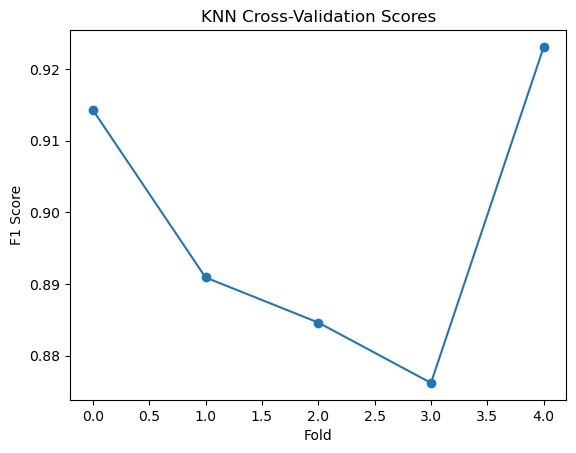

<Figure size 640x480 with 0 Axes>

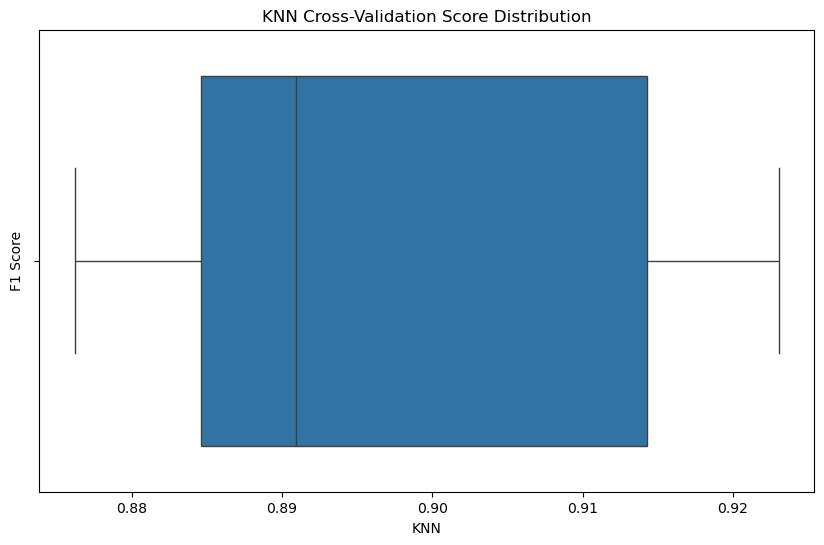

In [72]:
plt.plot(scores_knn, marker='o')
plt.title("KNN Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()
plt.savefig("model visuals/knn_cv_scores_line.png")

plt.figure(figsize=(10, 6))
sns.boxplot(x=scores_knn)
plt.title("KNN Cross-Validation Score Distribution")
plt.xlabel("KNN")
plt.ylabel("F1 Score")

plt.savefig("model visuals/knn_cv_scores.png")
plt.show()


### Hyperparameter Tuning (KNN)

In [68]:
param_grid = {
    'knn__n_neighbors': [3,5,7,11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best Params:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)
#print(" CV Score:", grid_knn.score)

Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best CV Score: 0.9159994751693883


### Final Evaluation (KNN)

In [69]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92        95
           1       1.00      0.83      0.91        95

    accuracy                           0.92       190
   macro avg       0.93      0.92      0.92       190
weighted avg       0.93      0.92      0.92       190

ROC AUC: 0.9157894736842105


####  CONFUSION MATRIX FOR KNN

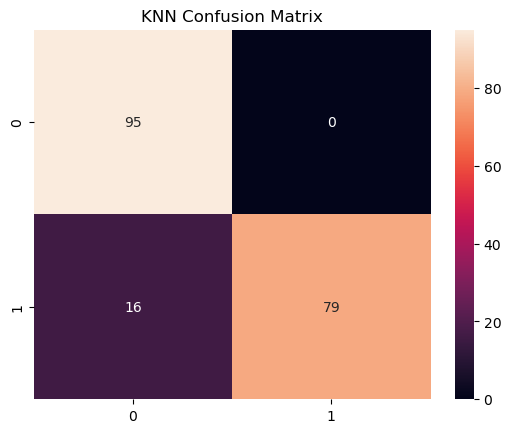

In [71]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")

plt.savefig("model visuals/knn_confusion_matrix.png")
plt.show()

* FN (missed fraud) = most dangerous

#### LOGREGRESSION MODEL


* Logistic Regression (Benchmark)

In [ ]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('lr', LogisticRegression(max_iter=1000))
])

#unvlidated code, just to check if it runs without error

pipeline_lr.fit(X_train_cleaned, y_train_cleaned)
ypred_logunvl = pipeline_lr.predict(X_test)

print(f"First 5 predictions from unvlidted pipeline: {ypred_logunvl[:5]}" )

scores_lr = cross_val_score(
    pipeline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Logistic Regression CV F1:", scores_lr.mean())
print("Logistic Regression CV Scores:", scores_lr[:5])

First 5 predictions from unvlidted pipeline: [1 0 1 0 1]
Logistic Regression CV F1: 0.9322930601650489
Logistic Regression CV Scores: [0.93150685 0.90909091 0.93055556 0.95238095 0.93793103]


##### Hyperparameter tuning Logistic regression model

In [ ]:
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)



GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs']},
             scoring='f1')

In [ ]:

print("Best Params:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)
print(" CV Score:", grid_lr.score)

Best Params: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best CV Score: 0.9322930601650489
 CV Score: <bound method BaseSearchCV.score of GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs']},
             scoring='f1')>


### Final Evaluation (Logistic Regression)

In [ ]:
best_lr = grid_lr.best_estimator_

y_pred_lr= best_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        95
           1       0.99      0.93      0.96        95

    accuracy                           0.96       190
   macro avg       0.96      0.96      0.96       190
weighted avg       0.96      0.96      0.96       190

ROC AUC: 0.9578947368421051


#####  CONFUSION MATRIX FOR Logistic Regression

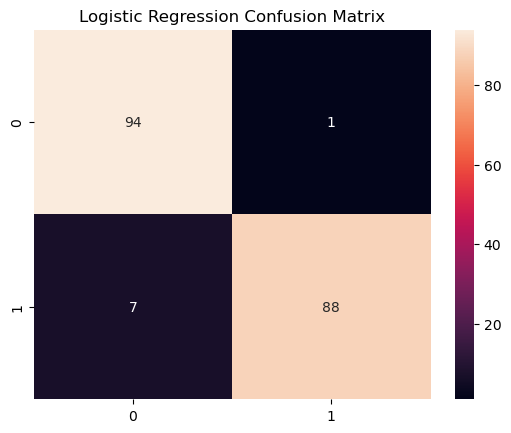

In [73]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("model visuals/logisticregression_confusion_matrix.png")
plt.show()

#### Boosting Model (Gradient Boosting)

In [ ]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('gb', GradientBoostingClassifier())
])

scores_gb = cross_val_score(
    pipeline_gb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Gradient Boosting CV F1:", scores_gb.mean())
print("Gradient Boosting CV Scores:", scores_gb[:5])

Gradient Boosting CV F1: 0.9190566592098659
Gradient Boosting CV Scores: [0.91275168 0.90277778 0.92307692 0.92517007 0.93150685]


#### Hyperparameter tuning Logistic regression model

In [ ]:
param_grid_gb = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.01, 0.1],
    'gb__max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('gb', GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.01, 0.1],
                         'gb__max_depth': [3, 5],
                         'gb__n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
print("Best Params:", grid_gb.best_params_)
print("Best CV Score:", grid_gb.best_score_)
print(" CV Score:", grid_gb.score)

Best Params: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 200}
Best CV Score: 0.9280839738140816
 CV Score: <bound method BaseSearchCV.score of GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('gb', GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.01, 0.1],
                         'gb__max_depth': [3, 5],
                         'gb__n_estimators': [100, 200]},
             scoring='f1')>


### Final Evaluation (Gradient Boosting)

In [ ]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        95
           1       1.00      0.89      0.94        95

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190

ROC AUC: 0.9473684210526316


#####  CONFUSION MATRIX FOR Logistic Regression

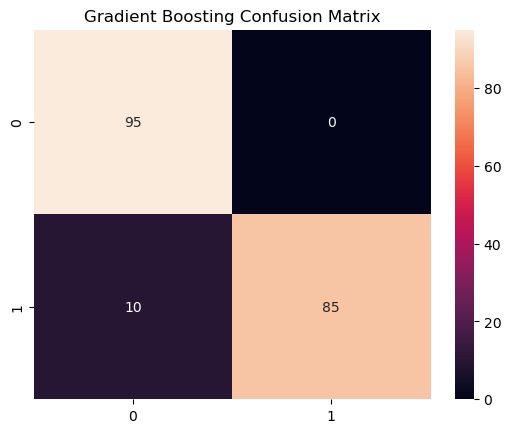

In [74]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d')
plt.title("Gradient Boosting Confusion Matrix")

plt.savefig("model visuals/Gradientboosting_confusion_matrix.png")
plt.show()

### Model Comparison (Visual)

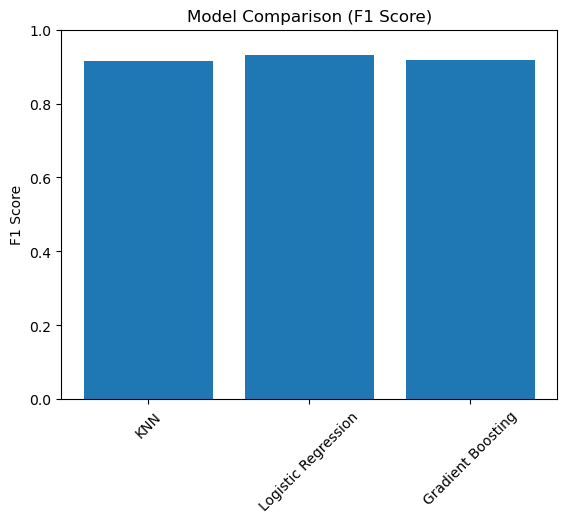

In [75]:
models = ['KNN', 'Logistic Regression', 'Gradient Boosting']
scores = [
    grid_knn.best_score_,
    scores_lr.mean(),
    scores_gb.mean()
]

plt.bar(models, scores)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.savefig("model visuals/model_comparison.png")
plt.show()

In [ ]:
best_model = max(
    [
        ('KNN', best_knn),
        ('LR', pipeline_lr.fit(X_train, y_train)),
        ('GB', pipeline_gb.fit(X_train, y_train))
    ],
    key=lambda x: roc_auc_score(y_test, x[1].predict(X_test))
)

print("Best Model:", best_model[0])

Best Model: LR


In [ ]:
best_knn = grid_knn.best_estimator_
best_lr  = grid_lr.best_estimator_
best_gb  = grid_gb.best_estimator_

print("Best Params KNN:", grid_knn.best_params_)
print("Best Params LR:", grid_lr.best_params_)
print("Best Params GB:", grid_gb.best_params_)

Best Params KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}
Best Params LR: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best Params GB: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 200}


####  Best cv scores for each model

In [ ]:
# Collecting CV scores for all models
cv_scores = [
    grid_knn.best_score_,
    grid_lr.best_score_,
    grid_gb.best_score_
]

for i in cv_scores :
    print(f"CV Score: {i}")

CV Score: 0.9159994751693883
CV Score: 0.9322930601650489
CV Score: 0.9280839738140816


#### Final comparison  (Comparing the  TEST scores)

In [ ]:
from sklearn.metrics import f1_score

knn_f1 = f1_score(y_test, best_knn.predict(X_test))
lr_f1  = f1_score(y_test, best_lr.predict(X_test))
gb_f1  = f1_score(y_test, best_gb.predict(X_test))

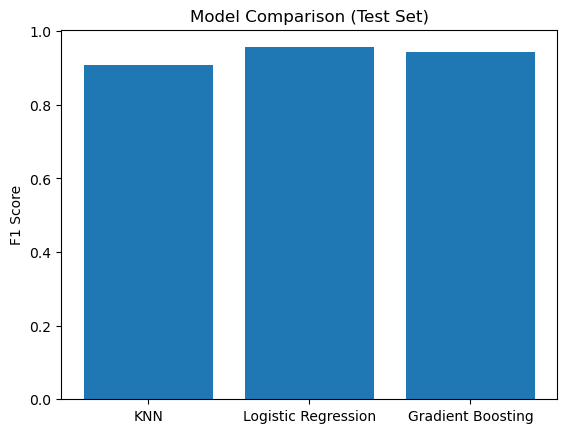

In [76]:
models = ['KNN', 'Logistic Regression', 'Gradient Boosting']
test_scores = [knn_f1, lr_f1, gb_f1]

plt.bar(models, test_scores)
plt.ylabel("F1 Score")
plt.title("Model Comparison (Test Set)")
plt.savefig("model visuals/model_comparison_test.png")  
plt.show()

In [ ]:
print("=== CV Scores ===")
print("KNN:", grid_knn.best_score_)
print("LR:", grid_lr.best_score_)
print("GB:", grid_gb.best_score_)

print("\n=== TEST Scores ===")
print("KNN:", knn_f1)
print("LR:", lr_f1)
print("GB:", gb_f1)

=== CV Scores ===
KNN: 0.9159994751693883
LR: 0.9322930601650489
GB: 0.9280839738140816

=== TEST Scores ===
KNN: 0.9080459770114943
LR: 0.9565217391304348
GB: 0.9444444444444444


### Add XGBoost

Why XGBoost dominates fraud detection
 * Handles nonlinear patterns
 * Built-in regularization
 * Robust to feature interactions
 * Performs well on imbalanced tabular data

In [ ]:

pipeline_hgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
])

#### Hyperparameter Tuning (HGB)

In [ ]:
param_grid_hgb = {
    'hgb__max_depth': [None, 5, 10],
    'hgb__learning_rate': [0.01, 0.1],
    'hgb__max_iter': [100, 200],
    'hgb__l2_regularization': [0.0, 0.1]
}

grid_hgb = GridSearchCV(
    pipeline_hgb,
    param_grid_hgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_hgb.fit(X_train, y_train)

print("Best Params:", grid_hgb.best_params_)
print("Best CV Score:", grid_hgb.best_score_)
print("")

Best Params: {'hgb__l2_regularization': 0.0, 'hgb__learning_rate': 0.1, 'hgb__max_depth': 10, 'hgb__max_iter': 100}
Best CV Score: 0.924890747381637


#### Threshold Tuning

In [ ]:
y_probs = grid_hgb.best_estimator_.predict_proba(X_test)[:,1]


precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_custom = (y_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        95
           1       0.98      0.95      0.96        95

    accuracy                           0.96       190
   macro avg       0.96      0.96      0.96       190
weighted avg       0.96      0.96      0.96       190



In [ ]:
models = ['KNN', 'Logistic Regression', 'Gradient Boosting' , 'HB']
scores = [
    grid_knn.best_score_,
    scores_lr.mean(),
    scores_gb.mean()
    
]

plt.bar(models, scores)
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.show()